In [2]:
import cv2 as cv
from PIL import Image
from matplotlib import pyplot as plt
import pytesseract
import sys
import numpy as np
import os


In [3]:
image_file = "images/thunderbet_test.png"
img = cv.imread(image_file)


In [4]:
def display(im_path):
    dpi = 80
    im_data = plt.imread(im_path)
    if im_data.ndim == 2:
        height, width = im_data.shape
    else:
        height, width, depth = im_data.shape

    # what size does the figure need to be in inches to fit the image
    figsize = width / float(dpi), height / float(dpi)

    # create a figure of the right size with one axes that takes the full image
    fig = plt.figure(figsize=figsize)
    ax =fig.add_axes([0, 0, 1, 1])

    # hides spines, ticks
    ax.axis('off')

    ax.imshow(im_data, cmap='gray')

    plt.show()


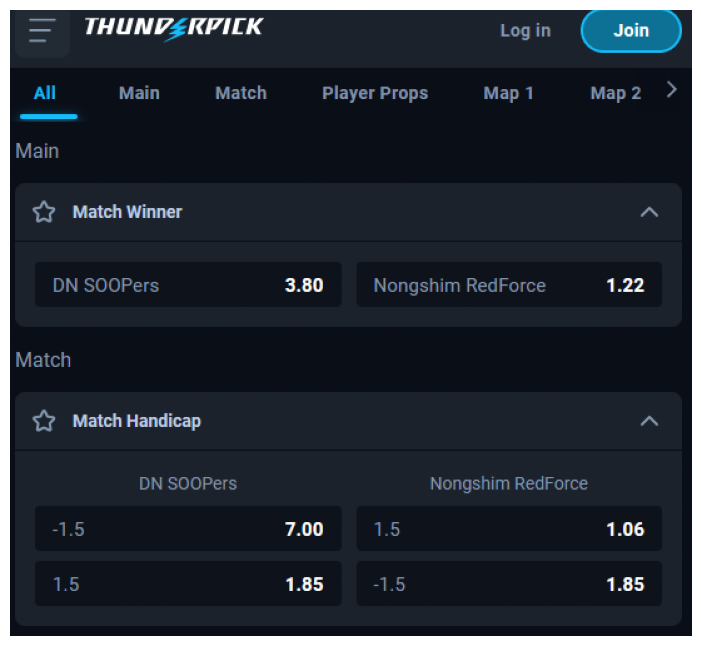

In [5]:
display(image_file)

### **1: Invert Images**

In [6]:
inverted_image = cv.bitwise_not(img)
cv.imwrite("temp/inverted.jpg", inverted_image)

True

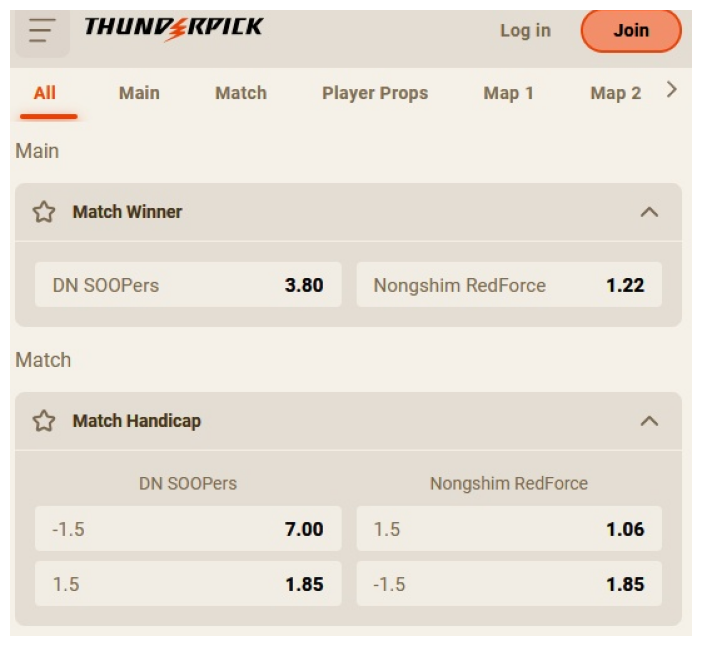

In [7]:
display("temp/inverted.jpg")

### **2: Rescaling**

### **3: Binarization** This honestly has the best result


Convert the image into black and white, grey scale

In [8]:
def grayscale(image):
    return cv.cvtColor(image, cv.COLOR_BGR2GRAY)

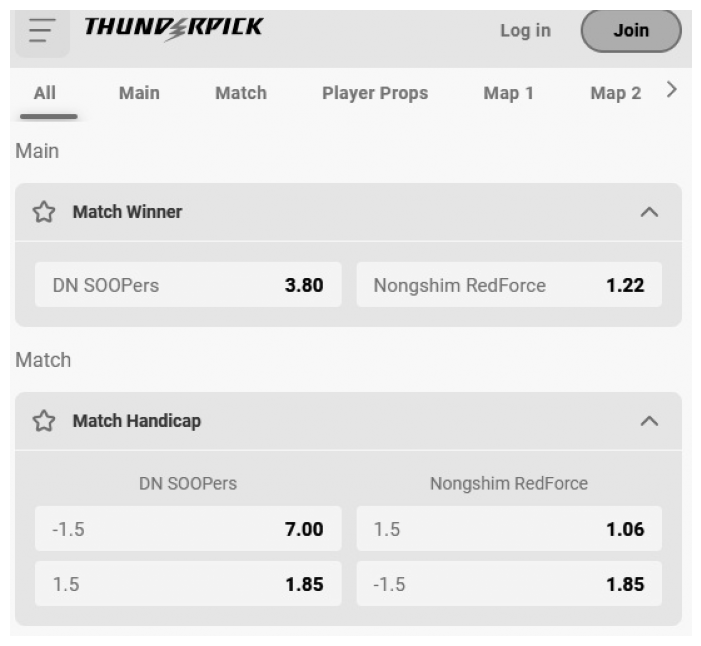

In [9]:
gray_image = grayscale(inverted_image)
cv.imwrite("temp/gs.jpg", gray_image)
display("temp/gs.jpg")

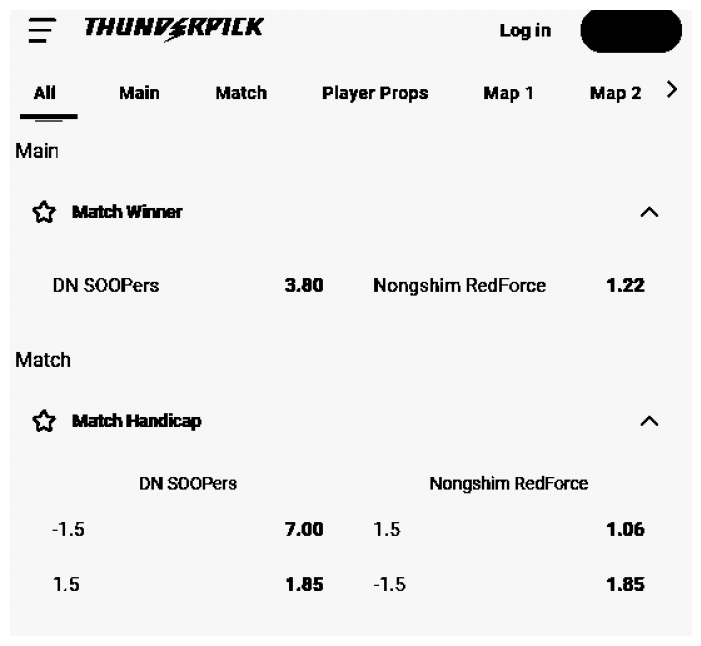

In [10]:
thresh, im_bw = cv.threshold(gray_image, 200, 230, cv.THRESH_BINARY)
cv.imwrite("temp/bw_image.jpg", im_bw)
display("temp/bw_image.jpg")

### **4: Noise removal**

In [11]:
def noise_removal(image):
    kernel = np.ones((1, 1), np.uint8)
    image = cv.dilate(image, kernel, iterations=1)
    kernel = np.ones((1, 1), np.uint8)
    image = cv.erode(image, kernel, iterations=1)
    image = cv.morphologyEx(image, cv.MORPH_CLOSE, kernel)
    image = cv.medianBlur(image, 3)
    return (image)

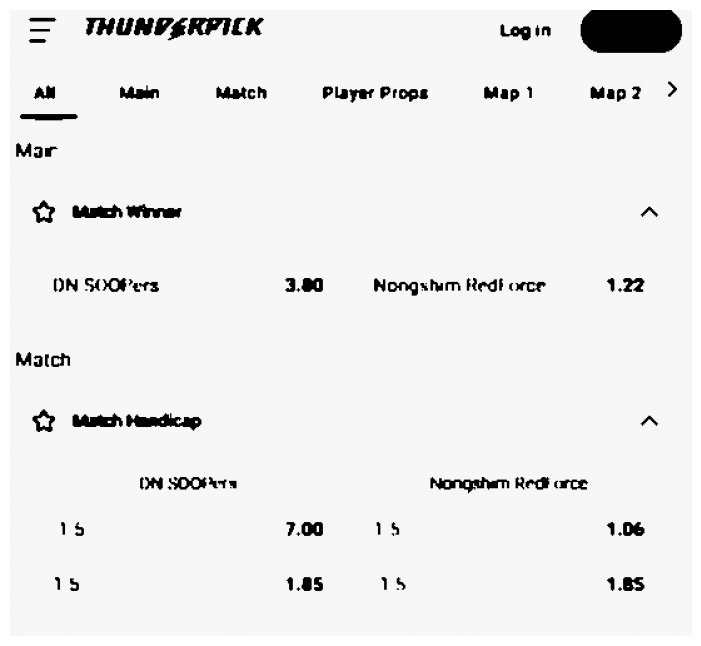

In [12]:
no_noise = noise_removal(im_bw) # honestly this is not needed, only needed if there is too muc hnoise which usually isnt
cv.imwrite("temp/no_noise.jpg", no_noise)
display("temp/no_noise.jpg")

### **5: Dilation and Erosion**

In [13]:
def thin_font(image):
    image = cv.bitwise_not(image)
    kernel = np.ones((2, 2), np.uint8)
    image = cv.erode(image, kernel, iterations=1)
    image = cv.bitwise_not(image)
    return image

def thick_font(image):
    image = cv.bitwise_not(image)
    kernel = np.ones((2, 2), np.uint8)
    image = cv.dilate(image, kernel, iterations=1)
    image = cv.bitwise_not(image)
    return image

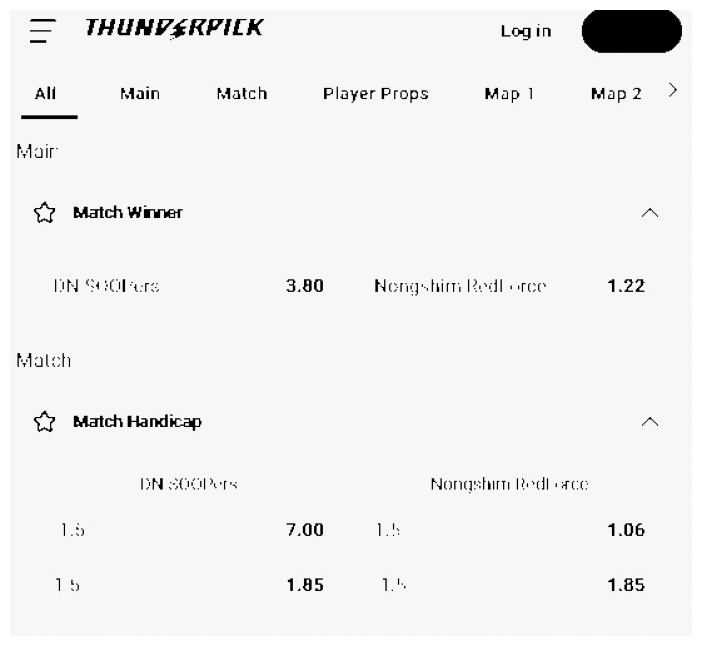

In [14]:
thinned_img = thin_font(im_bw)
cv.imwrite("temp/eroded_img.jpg", thinned_img)
display("temp/eroded_img.jpg")

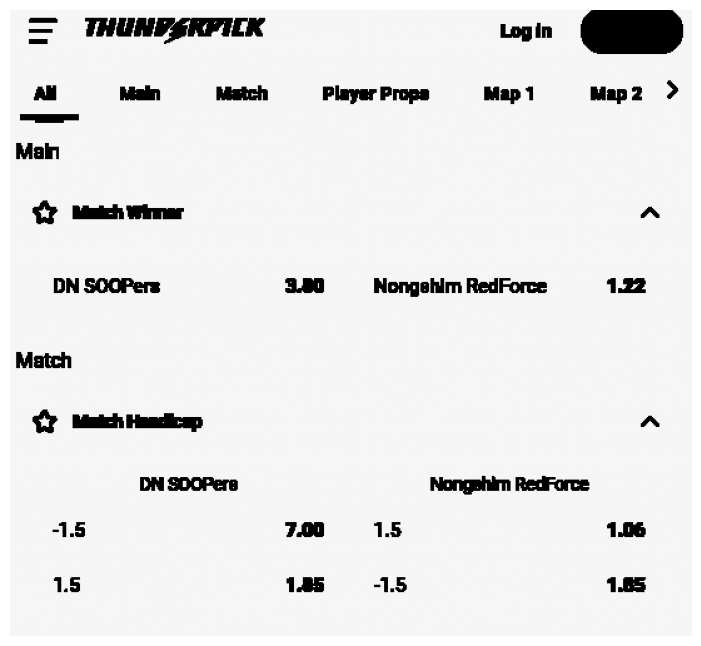

In [15]:
thick_img = thick_font(im_bw)
cv.imwrite("temp/thick_img.jpg", thick_img)
display("temp/thick_img.jpg")

### 6: Remove borders

In [16]:
def remove_borders(image):
    contours, heiarchy = cv.findContours(image, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)
    cntsSorted = sorted(contours, key=lambda x:cv.contourArea(x))
    cnt = cntsSorted[-1]
    x, y, w, h = cv.boundingRect(cnt)
    crop = image[y:y+h, x:x+w]
    return (crop)

### Work progress looks like
1. load file
2. invert it `cv.bitwise_not(img)`
3. greyscale it `cv.cvtColor(image, cv.COLOR_BGR2GRAY)`
4. binarize it `cv.threshold(gray_image, 200, 230, cv.THRESH_BINARY)`

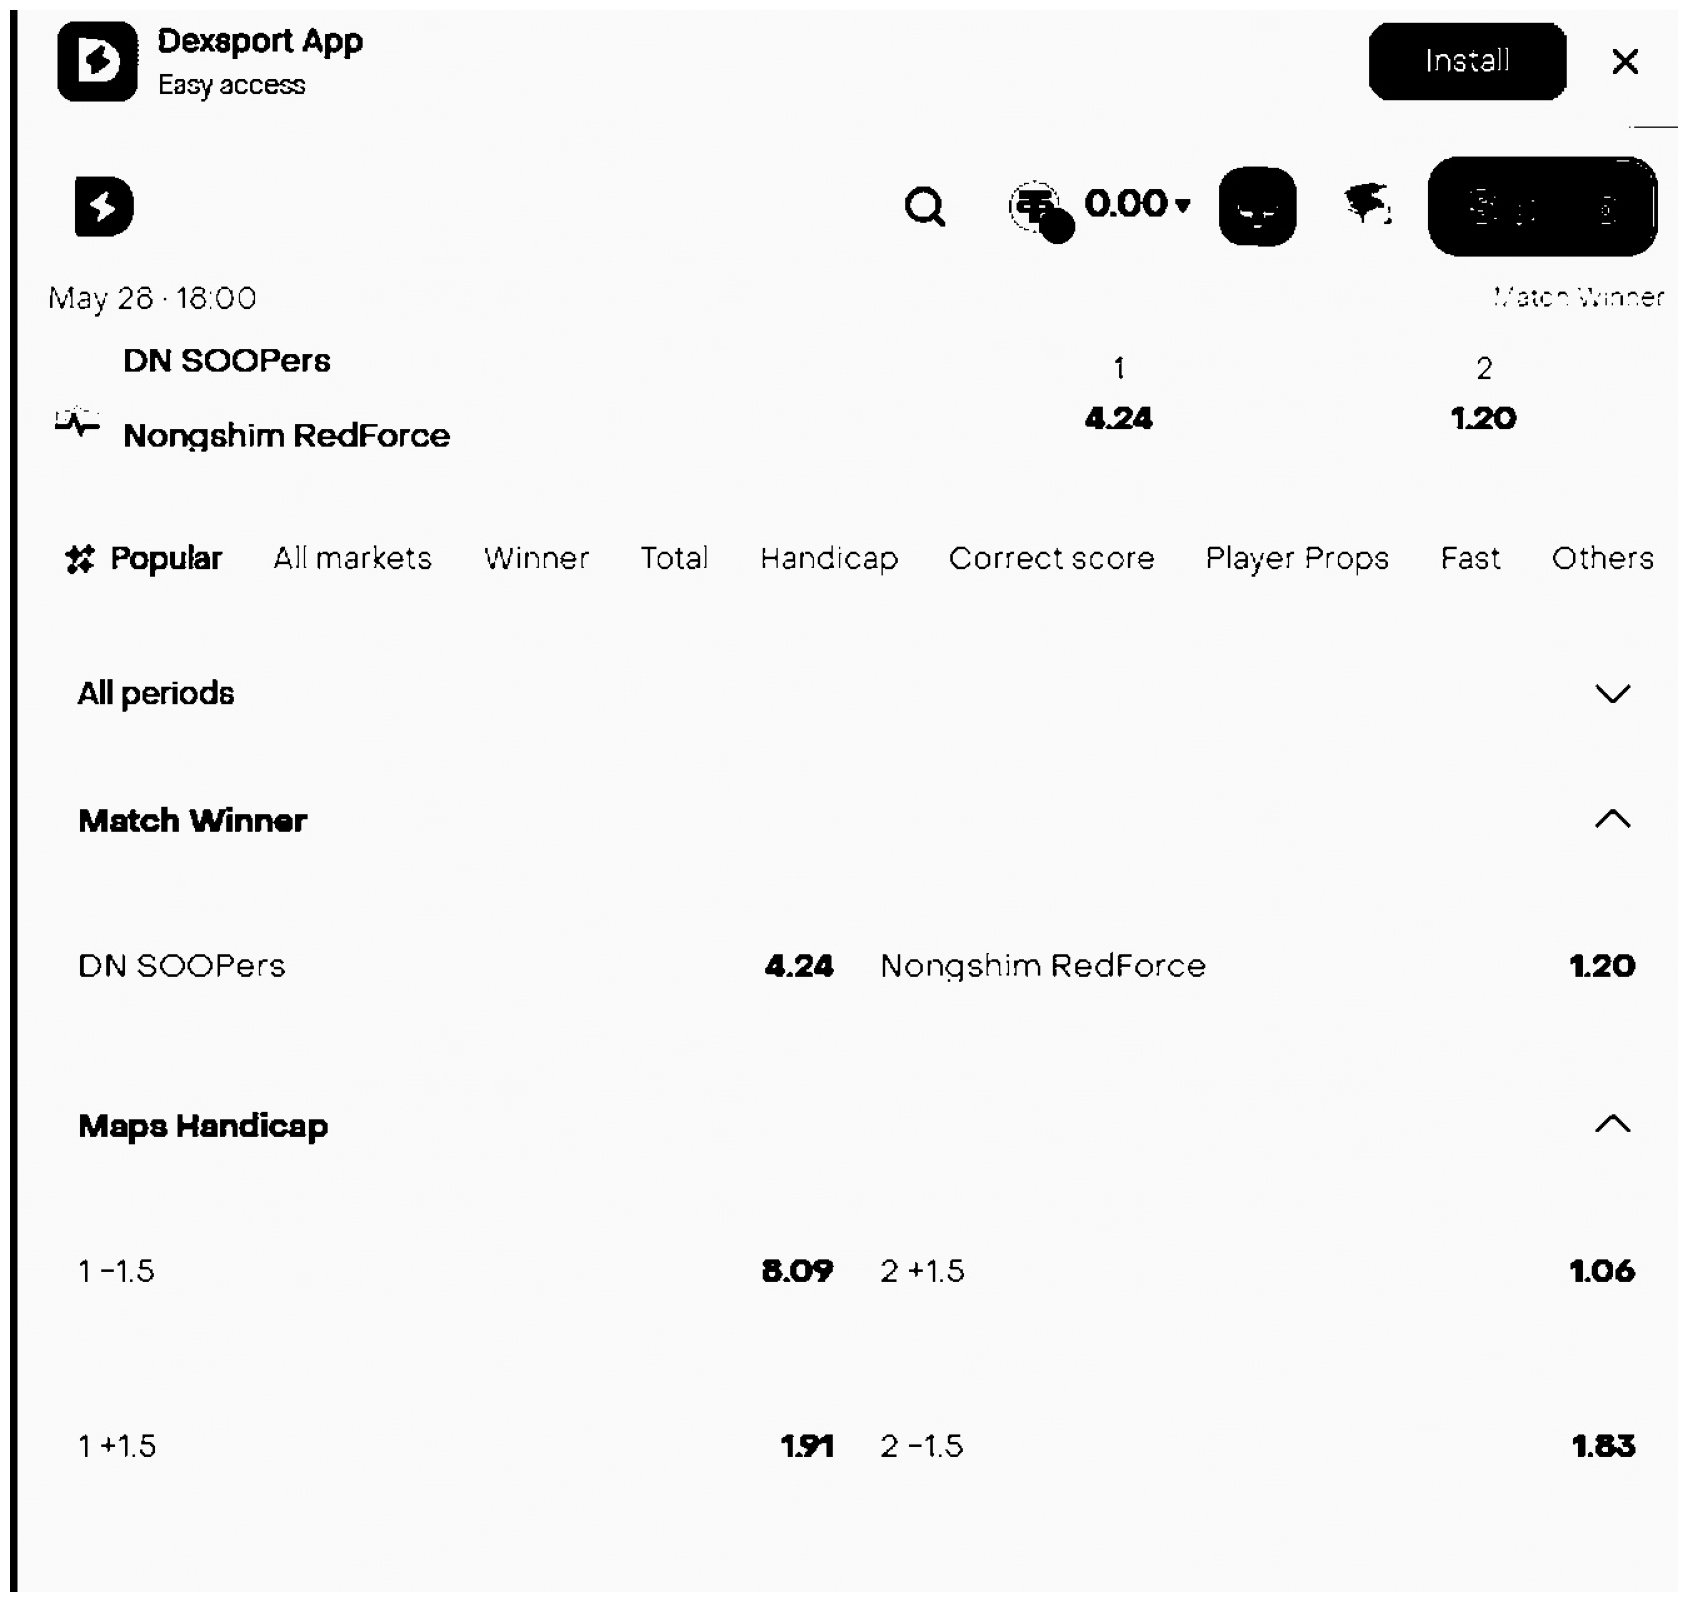

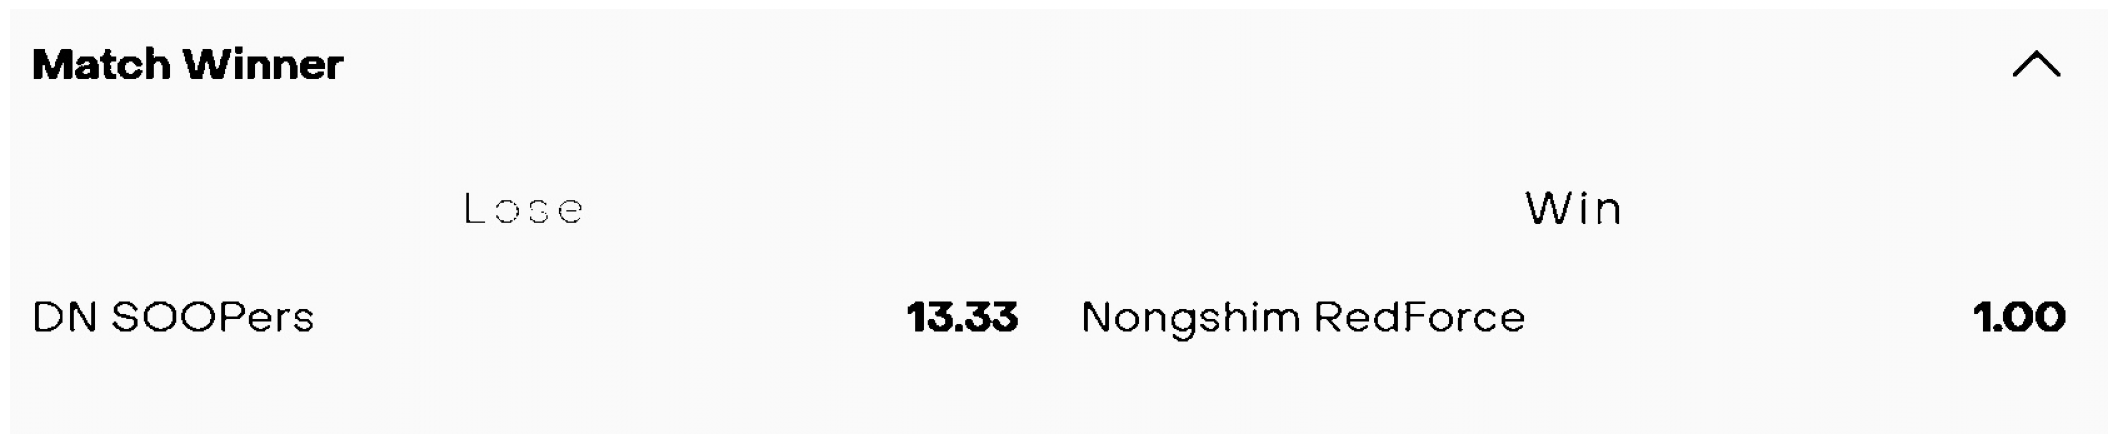

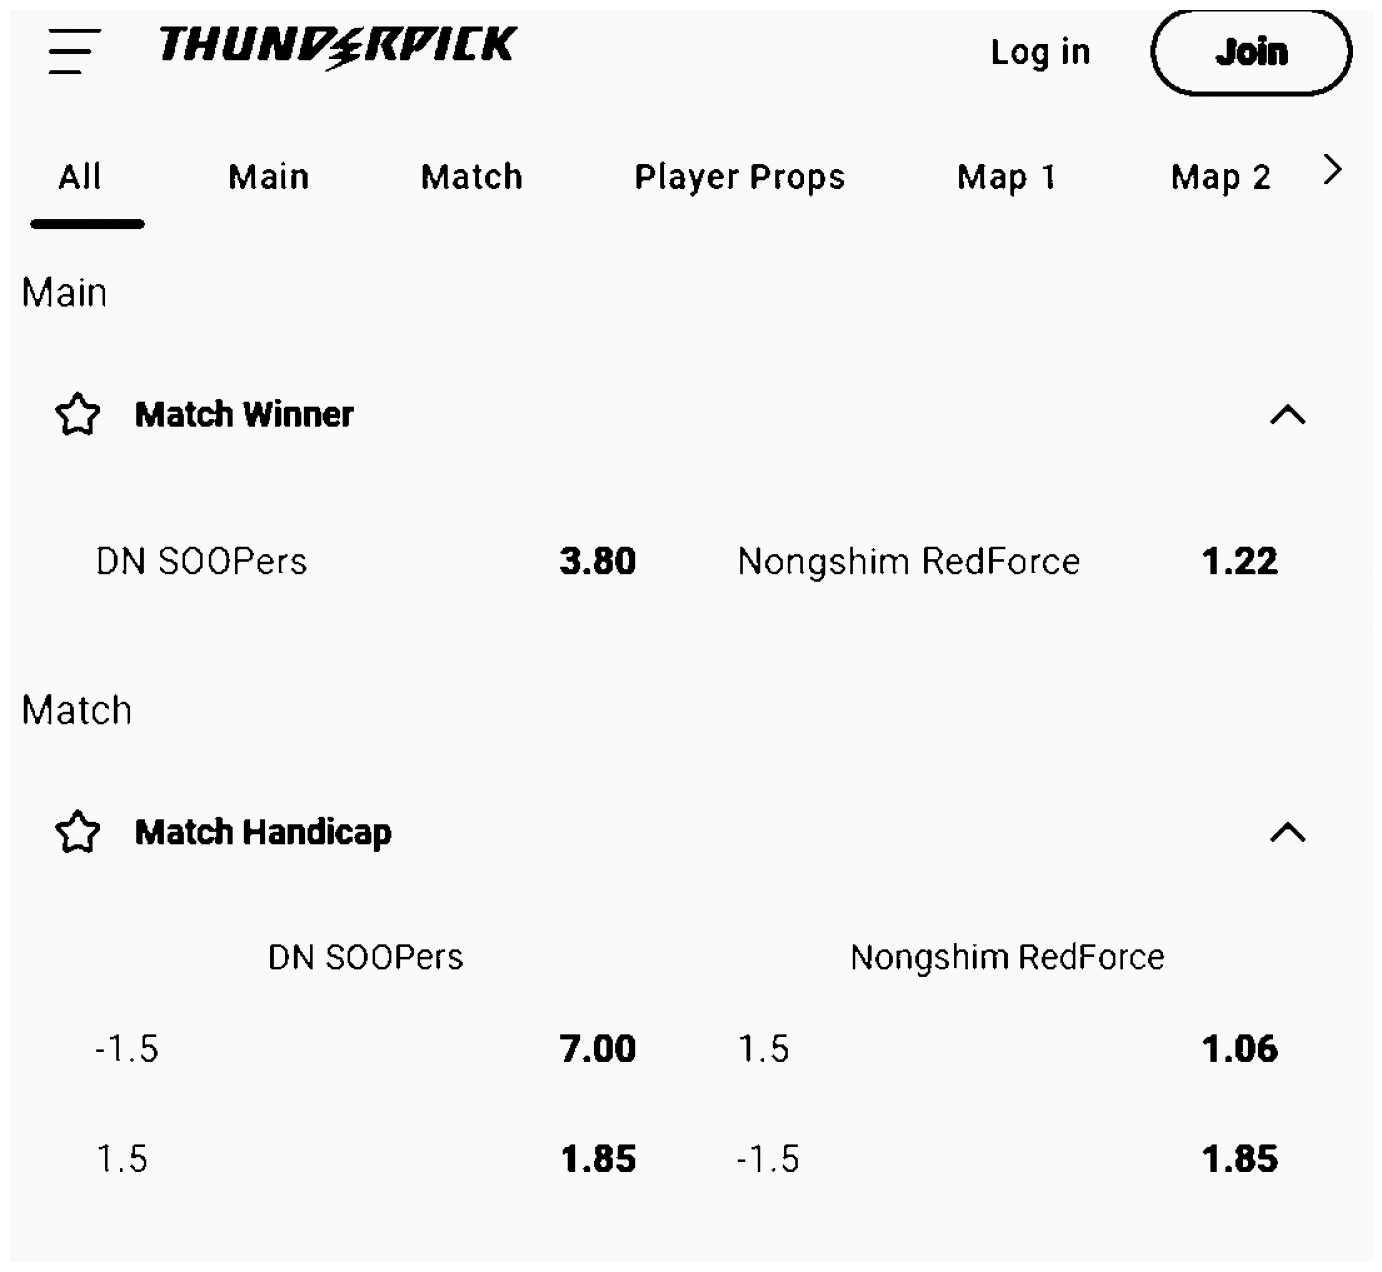

In [26]:
import cv2 as cv
from PIL import Image
from matplotlib import pyplot as plt
import pytesseract
import sys
import numpy as np
import os
for filename in os.listdir("images"):
    filepath = os.path.join("images", filename)
    img = cv.imread(filepath)
    img = cv.bitwise_not(img) # invert
    img = cv.cvtColor(img, cv.COLOR_BGR2GRAY) # greyscale
    img = cv.resize(img, None, fx=2, fy=2, interpolation=cv.INTER_CUBIC)
    # img =  thick_font(img)
    _, final = cv.threshold(img, 150, 250, cv.THRESH_BINARY) # binarize

    name = os.path.splitext(filename)[0]
    cv.imwrite(f"temp/{name}.jpg", final)
    display(f"temp/{name}.jpg")

In [18]:
print(1/2.90+ 1/1.65) # 20% cash back on 1.65 side

0.9508881922675027
